In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\HP\Desktop\retailpulse_project\data\processed\cleaned_data.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [9]:
# Insight:
# Top products are mostly small retail items

In [10]:
df = df.drop_duplicates()

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392692 non-null  int64  
 1   StockCode    392692 non-null  str    
 2   Description  392692 non-null  str    
 3   Quantity     392692 non-null  int64  
 4   InvoiceDate  392692 non-null  str    
 5   UnitPrice    392692 non-null  float64
 6   CustomerID   392692 non-null  float64
 7   Country      392692 non-null  str    
 8   TotalPrice   392692 non-null  float64
dtypes: float64(3), int64(2), str(4)
memory usage: 27.0 MB


In [12]:
df.describe()

,InvoiceNo,Quantity,UnitPrice,CustomerID,TotalPrice
count,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000
mean,560590.875047,13.119702,3.125914,15287.843865,22.631500
std,13087.063759,180.492832,22.241836,1713.539549,311.099224
min,536365.000000,1.000000,0.001000,12346.000000,0.001000
25%,549234.000000,2.000000,1.250000,13955.000000,4.950000
50%,561874.000000,6.000000,1.950000,15150.000000,12.450000
75%,572061.000000,12.000000,3.750000,16791.000000,19.800000
max,581587.000000,80995.000000,8142.750000,18287.000000,168469.600000


In [13]:


df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
dtype: int64

In [14]:
print(df.shape)

(392692, 9)


In [15]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [16]:
df.dtypes

InvoiceNo               int64
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
TotalPrice            float64
dtype: object

In [18]:
df['CustomerID'] = df['CustomerID'].fillna('Unknown')

In [19]:
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

In [20]:
df = df[df['Quantity'] > 0]

df = df[df['UnitPrice'] > 0]

In [21]:
df['Sales'] = df['Quantity'] * df['UnitPrice']

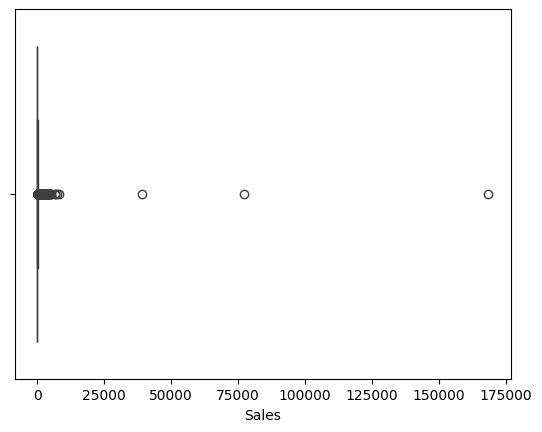

In [22]:
sns.boxplot(x=df['Sales'])
plt.show()

In [23]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [24]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Sales': 'sum'
})

In [26]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [27]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34


In [29]:
rfm['R_Score'] = pd.qcut(rfm['Recency'],
                         4,
                         labels=[4,3,2,1])

rfm['F_Score'] = pd.qcut(rfm['Frequency']
                         .rank(method='first'),
                         4,
                         labels=[1,2,3,4])

rfm['M_Score'] = pd.qcut(rfm['Monetary'],
                         4,
                         labels=[1,2,3,4])

In [31]:
#total score
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

In [35]:
rfm.to_csv(r'C:\Users\HP\Desktop\retailpulse_project\outputs\rfm_features.csv')


In [36]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,114
12347.0,2,7,4310.00,4,4,4,444
12348.0,75,4,1797.24,2,3,4,234
12349.0,19,1,1757.55,3,1,4,314
12350.0,310,1,334.40,1,1,2,112


In [40]:
#create dailyyyy datasettt

daily_sales = (
    df.groupby('InvoiceDate')['Sales']
      .sum()
      .reset_index()
)

daily_sales = daily_sales.sort_values('InvoiceDate')

In [41]:
# 7 day movng avg

daily_sales['rolling_mean_7'] = (
    daily_sales['Sales']
    .rolling(window=7)
    .mean()
)

In [42]:
# 30 days movng avg
daily_sales['rolling_mean_30'] = (
    daily_sales['Sales']
    .rolling(window=30)
    .mean()
)



In [43]:
# create standard deviation
daily_sales['rolling_std_30'] = (
    daily_sales['Sales']
    .rolling(window=30)
    .std()
)


In [44]:
daily_sales.head(15)

,InvoiceDate,Sales,rolling_mean_7,rolling_mean_30,rolling_std_30
0,2010-12-01 08:26:00,139.12,NaN,NaN,NaN
1,2010-12-01 08:28:00,22.20,NaN,NaN,NaN
2,2010-12-01 08:34:00,348.78,NaN,NaN,NaN
3,2010-12-01 08:35:00,17.85,NaN,NaN,NaN
4,2010-12-01 08:45:00,855.86,NaN,NaN,NaN
5,2010-12-01 09:00:00,204.00,NaN,NaN,NaN
6,2010-12-01 09:01:00,22.20,230.001429,NaN,NaN
7,2010-12-01 09:02:00,259.86,247.250000,NaN,NaN
8,2010-12-01 09:09:00,350.40,294.135714,NaN,NaN
9,2010-12-01 09:32:00,588.66,328.404286,NaN,NaN


In [47]:
daily_sales.to_csv(r'C:\Users\HP\Desktop\retailpulse_project\data\processed\time_series_features.csv')

In [48]:
daily_sales.head()

,InvoiceDate,Sales,rolling_mean_7,rolling_mean_30,rolling_std_30
0,2010-12-01 08:26:00,139.12,NaN,NaN,NaN
1,2010-12-01 08:28:00,22.20,NaN,NaN,NaN
2,2010-12-01 08:34:00,348.78,NaN,NaN,NaN
3,2010-12-01 08:35:00,17.85,NaN,NaN,NaN
4,2010-12-01 08:45:00,855.86,NaN,NaN,NaN


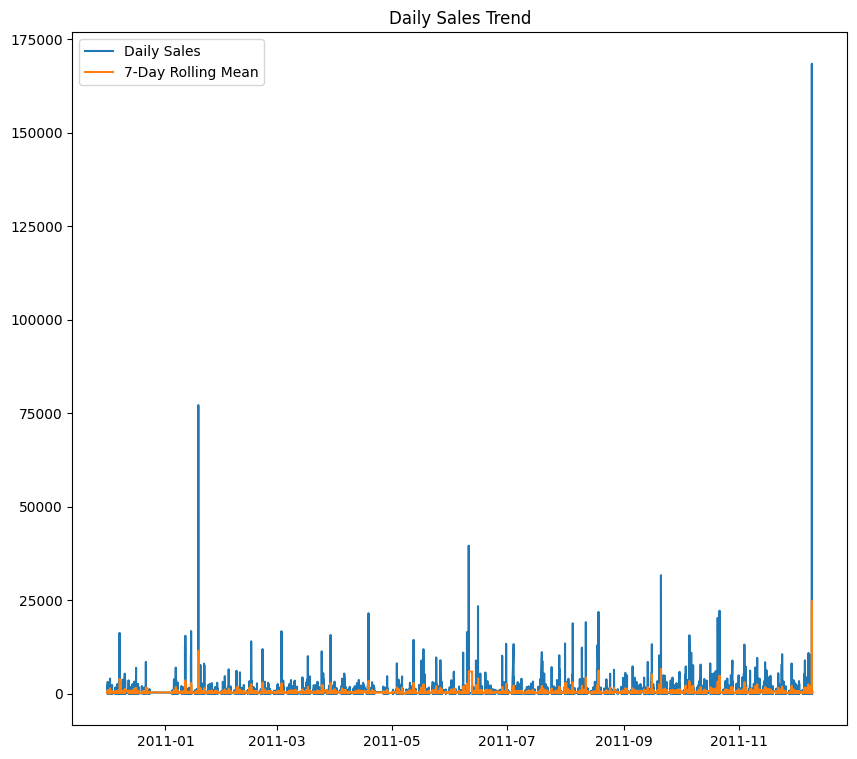

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,9))

plt.plot(daily_sales['InvoiceDate'],
         daily_sales['Sales'],
         label='Daily Sales')

plt.plot(daily_sales['InvoiceDate'],
         daily_sales['rolling_mean_7'],
         label='7-Day Rolling Mean')

plt.legend()
plt.title('Daily Sales Trend')
plt.show()

In [51]:
# Missing values
print("=== Missing Values ===")
print(df.isnull().sum())


print("\n=== Duplicate Rows ===")
print(df.duplicated().sum())


print("\n=== Negative Quantity ===")
print((df['Quantity'] < 0).sum())

print("\n=== Negative Sales ===")
print((df['Sales'] < 0).sum())

# Data types
print("\n=== Data Types ===")
print(df.dtypes)

=== Missing Values ===
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
Sales          0
dtype: int64

=== Duplicate Rows ===
0

=== Negative Quantity ===
0

=== Negative Sales ===
0

=== Data Types ===
InvoiceNo               int64
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
TotalPrice            float64
Sales                 float64
dtype: object


In [52]:
validation_results = {
    "Null CustomerID": df["CustomerID"].isnull().sum(),
    "Null Quantity": df["Quantity"].isnull().sum(),
    "Null Sales": df["Sales"].isnull().sum(),
    "Duplicate Rows": df.duplicated().sum(),
    "Negative Quantity": (df["Quantity"] < 0).sum(),
    "Negative Sales": (df["Sales"] < 0).sum()
}

validation_df = pd.DataFrame(
    validation_results.items(),
    columns=["Check", "Count"]
)

validation_df

,Check,Count
0,Null CustomerID,0
1,Null Quantity,0
2,Null Sales,0
3,Duplicate Rows,0
4,Negative Quantity,0
5,Negative Sales,0


In [59]:
validation_df.to_csv(r'C:\Users\HP\Desktop\retailpulse_project\data\processed\validation_report.csv',
    index=False
)